In [1]:
#IMPORTS
#=========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import median_abs_deviation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
roc_auc_score,
roc_curve,
classification_report,
confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
Dense,
Dropout,
BatchNormalization,
Input
)

from tensorflow.keras.callbacks import (
EarlyStopping,
ReduceLROnPlateau,
ModelCheckpoint
)

from tensorflow.keras.regularizers import l2

In [2]:
#PATHS
#=========================================================

BASE_DL = r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL"

PATHS = {

"cgga693_clin":
    BASE_DL + r"\CGGA.mRNAseq_693_clinical.20200506.txt\CGGA.mRNAseq_693_clinical.20200506.txt",

"cgga325_clin":
    BASE_DL + r"\CGGA.mRNAseq_325_clinical.20200506.txt\CGGA.mRNAseq_325_clinical.20200506.txt",

"cgga693_expr":
    BASE_DL + r"\CGGA.mRNAseq_693.Read_Counts-genes.20220620.txt\CGGA.mRNAseq_693.Read_Counts-genes.20220620.txt",

"cgga325_expr":
    BASE_DL + r"\CGGA.mRNAseq_325.Read_Counts-genes.20220620.txt\CGGA.mRNAseq_325.Read_Counts-genes.20220620.txt",

}


In [3]:
# =========================================================
# FILE LOADER
# =========================================================

def load_txt(path, **kwargs):

    for sep in ["\t", ","]:

        try:

            df = pd.read_csv(
                path,
                sep=sep,
                comment="#",
                **kwargs
            )

            if df.shape[1] > 1:
                return df

        except:
            pass

    raise ValueError(f"Cannot parse file: {path}")
#=========================================================
#LOAD DATA
#=========================================================

cgga693_clin = load_txt(PATHS["cgga693_clin"])

cgga325_clin = load_txt(PATHS["cgga325_clin"])

cgga693_expr = load_txt(
PATHS["cgga693_expr"],
index_col=0
)

cgga325_expr = load_txt(
PATHS["cgga325_expr"],
index_col=0
)

tcga_clin = pd.read_csv(
    r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL\DL2\tcga_clin_ready.csv"
)
tcga_expr = pd.read_csv(
    r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL\DL2\tcga_tcga_gbmlgg_expr.csv",
    compression="gzip",
    index_col=0
)

In [4]:
#CLEAN TCGA IDs
#=========================================================

def clean_tcga_id(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    x = x[:12]

    return x

In [5]:
# TMZ COLUMN
#=========================================================

def detect_tmz_col(clin_df):

    keywords = [
        "tmz",
        "temozolomide",
        "chemo",
        "chemotherapy",
        "treatment"
    ]

    for col in clin_df.columns:

        col_lower = col.lower()

        if any(k in col_lower for k in keywords):
            return col

    raise ValueError("TMZ column not found")

In [6]:
# =========================================================
# PREPROCESS CGGA
# =========================================================

def preprocess_cgga(expr_df, clin_df, batch_name):

    clin = clin_df.copy()

    # -----------------------------------------------------
    # Detect sample ID column
    # -----------------------------------------------------
    id_col = next(
        (
            c for c in clin.columns
            if "id" in c.lower()
        ),
        clin.columns[0]
    )

    tmz_col = detect_tmz_col(clin)

    # -----------------------------------------------------
    # TMZ labels
    # -----------------------------------------------------
    vals = clin[tmz_col].astype(str).str.lower()

    clin["TMZ_label"] = np.nan

    clin.loc[
        vals.str.contains(
            "tmz|treated|yes|1",
            na=False
        ),
        "TMZ_label"
    ] = 1

    clin.loc[
        vals.str.contains(
            "untreated|control|no|0",
            na=False
        ),
        "TMZ_label"
    ] = 0

    clin = clin[
        clin["TMZ_label"].notna()
    ].copy()

    clin["TMZ_label"] = (
        clin["TMZ_label"]
        .astype(int)
    )

    # -----------------------------------------------------
    # Align samples
    # -----------------------------------------------------
    sample_ids = (
        clin[id_col]
        .astype(str)
    )

    sample_ids = sample_ids[
        sample_ids.isin(expr_df.columns)
    ]

    expr_sub = expr_df.loc[:, sample_ids]

    clin_sub = (
        clin
        .set_index(id_col)
        .loc[sample_ids]
        .reset_index()
    )

    clin_sub["sample_id"] = sample_ids.values
    clin_sub["batch"] = batch_name

    return expr_sub, clin_sub

In [7]:
# =========================================================
# PREPROCESS TCGA
# =========================================================

def preprocess_tcga(expr_df, clin_df):

    clin = clin_df.copy()

    # correct ID column
    id_col = "SAMPLE_ID"

    clin[id_col] = clin[id_col].apply(clean_tcga_id)

    clin = clin.dropna(subset=[id_col])
    clin = clin.drop_duplicates(subset=[id_col])

    sample_ids = [s for s in clin[id_col] if s in expr_df.columns]

    expr_sub = expr_df.loc[:, sample_ids]

    clin_sub = clin.set_index(id_col).loc[sample_ids].reset_index()

    clin_sub["sample_id"] = sample_ids

    return expr_sub, clin_sub

In [8]:
# =========================================================
# RUN PREPROCESSING
# =========================================================

# ---------------------------
# CGGA 693
# ---------------------------
cgga693_e, cgga693_c = preprocess_cgga(
    cgga693_expr,
    cgga693_clin,
    "CGGA693"
)

# ---------------------------
# CGGA 325
# ---------------------------
cgga325_e, cgga325_c = preprocess_cgga(
    cgga325_expr,
    cgga325_clin,
    "CGGA325"
)

In [9]:
# common genes between CGGA datasets
common_genes = sorted(
    cgga693_e.index.intersection(cgga325_e.index)
)

cgga693_e = cgga693_e.loc[common_genes]
cgga325_e = cgga325_e.loc[common_genes]

# merge expression (samples)
cgga_expr = pd.concat(
    [cgga693_e, cgga325_e],
    axis=1
)

# add batch info (VERY IMPORTANT)
cgga693_c["batch"] = "CGGA693"
cgga325_c["batch"] = "CGGA325"

cgga_clin = pd.concat(
    [cgga693_c, cgga325_c],
    axis=0,
    ignore_index=True
)

# TCGA preprocessing
tcga_expr, tcga_clin = preprocess_tcga(tcga_expr, tcga_clin)

# align gene space across ALL datasets
common_genes = sorted(
    cgga_expr.index.intersection(tcga_expr.index)
)

cgga_expr = cgga_expr.loc[common_genes]
tcga_expr = tcga_expr.loc[common_genes]

In [10]:
# =========================================================
# CLEAN EXPRESSION VALUES
# =========================================================

cgga_expr = cgga_expr.apply(pd.to_numeric, errors="coerce")
tcga_expr = tcga_expr.apply(pd.to_numeric, errors="coerce")

# replace infinities with NaN
cgga_expr = cgga_expr.replace([np.inf, -np.inf], np.nan)
tcga_expr = tcga_expr.replace([np.inf, -np.inf], np.nan)

# fill missing values
cgga_expr = cgga_expr.fillna(0)
tcga_expr = tcga_expr.fillna(0)

# =========================================================
# REMOVE NEGATIVE VALUES
# =========================================================

cgga_expr[cgga_expr < 0] = 0
tcga_expr[tcga_expr < 0] = 0

# =========================================================
# LOG2 NORMALIZATION
# =========================================================

cgga_expr = np.log2(cgga_expr + 1)
tcga_expr = np.log2(tcga_expr + 1)

In [11]:
# =========================================================
# REMOVE NON-CODING / LOW-QUALITY GENES
# =========================================================

bad_patterns = (
    "RP11-",
    "RP5-",
    "RP1-",
    "LINC",
    "MIR",
    "SNORD",
    "AC",
    "AL",
    "AP"
)

good_genes = []

for g in cgga_expr.index:

    g = str(g)

    # Remove unwanted gene patterns
    if any(p in g for p in bad_patterns):
        continue

    # Remove invalid gene names
    if g.startswith("."):
        continue

    if len(g) < 2:
        continue

    good_genes.append(g)

# =========================================================
# Keep filtered genes
# =========================================================

cgga_expr = cgga_expr.loc[good_genes]
tcga_expr = tcga_expr.loc[good_genes]

In [12]:
# =========================================================
# BUILD BIOLOGICAL TMZ RESISTANCE LABELS
# =========================================================

df = cgga_clin.copy()

tmz_col = "Chemo_status (TMZ treated=1;un-treated=0)"
mgmt_col = "MGMTp_methylation_status"
os_col = "OS"

# ---------------------------------------------------------
# Clean metadata columns
# ---------------------------------------------------------

df[tmz_col] = (
    df[tmz_col]
    .astype(str)
    .str.lower()
)

df[mgmt_col] = (
    df[mgmt_col]
    .astype(str)
    .str.lower()
)

df[os_col] = pd.to_numeric(
    df[os_col],
    errors="coerce"
)

# =========================================================
# TMZ RESISTANCE SIGNATURE
# =========================================================

TR_marker = [
    "PAPPA",
    "ANXA3",
    "LRRC3",
    "EGR4"
]

available_genes = [
    g for g in TR_marker
    if g in cgga_expr.index
]

print("Available TR genes:", available_genes)

# ---------------------------------------------------------
# Compute resistance score
# ---------------------------------------------------------

TR_score = (
    cgga_expr
    .loc[available_genes]
    .mean(axis=0)
)

df["TR_score"] = (
    df["sample_id"]
    .map(TR_score)
)

df["TR_score"] = (
    df["TR_score"]
    .fillna(df["TR_score"].median())
)

# =========================================================
# MEDIAN SPLITS
# =========================================================

os_median = df[os_col].median()
tr_median = df["TR_score"].median()

# =========================================================
# BASIC FEATURES
# =========================================================

tmz_treated = df[tmz_col].str.contains(
    "1|yes|tmz|treated",
    na=False
)

mgmt_methyl = df[mgmt_col].str.contains(
    "methylated",
    na=False
)

# =========================================================
# RESISTANCE SCORE
# =========================================================

resistance_score = (

    (~mgmt_methyl).astype(int) +

    (df[os_col] < os_median).astype(int) +

    (df["TR_score"] >= tr_median).astype(int)

)

# =========================================================
# FINAL LABELS
#
# 0 = Sensitive
# 1 = Resistant
# =========================================================

df["TMZ_response"] = np.nan

df.loc[
    resistance_score <= 1,
    "TMZ_response"
] = 0

df.loc[
    resistance_score >= 2,
    "TMZ_response"
] = 1

# =========================================================
# KEEP TMZ-TREATED ONLY
# =========================================================

df = df[
    tmz_treated
].copy()

df = df[
    df["TMZ_response"].notna()
].copy()

df["TMZ_response"] = (
    df["TMZ_response"]
    .astype(int)
)

# =========================================================
# LABEL SUMMARY
# =========================================================

print("\nTMZ LABEL SUMMARY")
print(df["TMZ_response"].value_counts())

Available TR genes: ['ANXA3', 'LRRC3', 'EGR4']

TMZ LABEL SUMMARY
TMZ_response
0    469
1    210
Name: count, dtype: int64


In [13]:
# MAD FEATURE SELECTION

# =========================================================

gene_mad = pd.Series(
    [
        median_abs_deviation(
            cgga_expr.loc[g]
        )
        for g in cgga_expr.index
    ],
    index=cgga_expr.index
)

top_genes = (
gene_mad
.nlargest(3000)
.index
)

cgga_expr = cgga_expr.loc[top_genes]

tcga_expr = tcga_expr.loc[top_genes]

# =========================================================

# BUILD MATRICES

# =========================================================

X = cgga_expr.T.copy()

y = (
df
.set_index("sample_id")
.reindex(X.index)["TMZ_response"]
)

# remove missing labels safely
valid_samples = y.dropna().index

X = X.loc[valid_samples]
y = y.loc[valid_samples].astype(int)

# keep only matched samples
common_samples = (
X.index
.intersection(y.index)
)

X = X.loc[common_samples]
y = y.loc[common_samples]

X_test = tcga_expr.T.copy()

In [14]:
# TRAIN / VALIDATION SPLIT

# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# STANDARDIZATION
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# CLASS WEIGHTS
# =========================================================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(
    zip(np.unique(y_train), weights)
)

print(class_weight)

{np.int64(0): np.float64(0.724), np.int64(1): np.float64(1.6160714285714286)}


In [163]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Activation
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf

# =========================================================
# BUILD MLP (FUNCTIONAL API) - 128 BASE MODEL
# =========================================================

def build_mlp(input_dim):

    inputs = Input(
        shape=(input_dim,),
        name="Gene_Input"
    )

    # =====================================================
    # Hidden Layer 1 (128)
    # =====================================================
    x = Dense(
        128,
        kernel_regularizer=l2(1e-4),
        name="Dense_128"
    )(inputs)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.3)(x)

    # =====================================================
    # Hidden Layer 2 (64)
    # =====================================================
    x = Dense(
        64,
        kernel_regularizer=l2(1e-4),
        name="Dense_64"
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.3)(x)

    # =====================================================
    # Hidden Layer 3 (32)
    # =====================================================
    x = Dense(
        32,
        kernel_regularizer=l2(1e-4),
        name="Dense_32"
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)

    # =====================================================
    # Output Layer
    # =====================================================
    outputs = Dense(
        1,
        activation="sigmoid",
        name="TMZ_Resistance_Output"
    )(x)

    # =====================================================
    # Model
    # =====================================================
    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="TMZ_Resistance_MLP"
    )

    # =====================================================
    # Compile
    # =====================================================
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [164]:
# =========================================================
# MODEL
# =========================================================

model = build_mlp(
    X_train.shape[1]
)

model.summary()

Model: "TMZ_Resistance_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Gene_Input (InputLayer)              │ (None, 3000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_128 (Dense)                    │ (None, 128)                 │         384,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_64 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_32 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ TMZ_Resistance_Output (Dense)        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 395,393 (1.51 MB)

 Trainable params: 394,945 (1.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [339]:
# =========================================================
# CALLBACKS
# =========================================================

import tensorflow as tf
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=15,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# =========================================================
# K-FOLD SETUP
# =========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_aucs = []

best_auc = 0
best_model = None
best_scaler = None
best_threshold = 0.5

# store curves (optional)
train_losses = []
val_losses = []

# =========================================================
# K-FOLD TRAINING LOOP
# =========================================================

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\n================ FOLD {fold+1} ================\n")

    # -------------------------
    # Split
    # -------------------------
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # -------------------------
    # Scaling (IMPORTANT: inside fold)
    # -------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # -------------------------
    # Class weights
    # -------------------------
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight = dict(zip(np.unique(y_train), weights))

    # -------------------------
    # Build model (RESET EACH FOLD)
    # -------------------------
    tf.keras.backend.clear_session()

    model = build_mlp(X_train_scaled.shape[1])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    # -------------------------
    # Train
    # -------------------------
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=16,
        class_weight=class_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    train_losses.append(history.history["loss"])
    val_losses.append(history.history["val_loss"])

    # -------------------------
    # Predict
    # -------------------------
    val_probs = model.predict(X_val_scaled).ravel()

    auc = roc_auc_score(y_val, val_probs)
    fold_aucs.append(auc)

    print("Fold AUC:", round(auc, 4))

    # -------------------------
    # Threshold (Youden’s J)
    # -------------------------
    fpr, tpr, thresholds = roc_curve(y_val, val_probs)
    j_scores = tpr - fpr
    fold_threshold = thresholds[np.argmax(j_scores)]

    # -------------------------
    # Save best model
    # -------------------------
    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_scaler = scaler
        best_threshold = fold_threshold

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n================ FINAL K-FOLD RESULTS ================")
print("Mean AUC:", round(np.mean(fold_aucs), 4))
print("Std AUC:", round(np.std(fold_aucs), 4))
print("Best AUC:", round(best_auc, 4))
print("Best Threshold:", round(best_threshold, 4))

# =========================================================
# STORE BEST MODEL
# =========================================================

model = best_model
scaler = best_scaler


================ FOLD 1 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fold AUC: 0.7784

================ FOLD 2 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Fold AUC: 0.8455

================ FOLD 3 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Fold AUC: 0.8673

================ FOLD 4 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
Fold AUC: 0.8118

================ FOLD 5 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Fold AUC: 0.7483

================ FINAL K-FOLD RESULTS ================
Mean AUC: 0.8103
Std AUC: 0.0432
Best AUC: 0.8673
Best Threshold: 0.5393


In [340]:
# =========================================================
# FINAL VALIDATION (BEST MODEL FROM K-FOLD)
# =========================================================

# Scale test data using BEST scaler from training
X_val_scaled = best_scaler.transform(X_val)

# Predict probabilities
val_probs = best_model.predict(X_val_scaled).ravel()

# Apply optimal threshold (from best fold)
val_pred = (val_probs >= best_threshold).astype(int)

# AUC
auc = roc_auc_score(y_val, val_probs)

print("\n================ FINAL VALIDATION ================")
print("Final Validation AUC:", round(auc, 4))

# Classification report
print(classification_report(y_val, val_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

================ FINAL VALIDATION ================
Final Validation AUC: 0.9357
              precision    recall  f1-score   support

           0       0.99      0.81      0.89        93
           1       0.69      0.98      0.81        42

    accuracy                           0.86       135
   macro avg       0.84      0.89      0.85       135
weighted avg       0.90      0.86      0.86       135



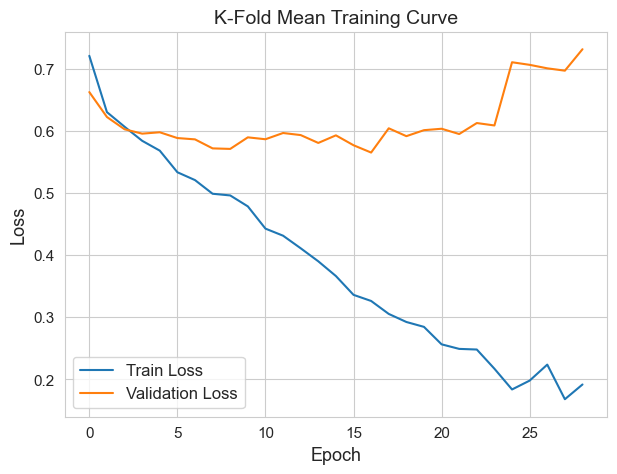

In [341]:
# LOSS CURVE VISUALIZATION (K-FOLD MEAN)
# =========================================================

max_epochs = max(len(x) for x in train_losses)

train_matrix = np.array([
    np.pad(x, (0, max_epochs - len(x)), constant_values=np.nan)
    for x in train_losses
])

val_matrix = np.array([
    np.pad(x, (0, max_epochs - len(x)), constant_values=np.nan)
    for x in val_losses
])

mean_train_loss = np.nanmean(train_matrix, axis=0)
mean_val_loss = np.nanmean(val_matrix, axis=0)

plt.figure(figsize=(7,5))

plt.plot(mean_train_loss, label="Train Loss")
plt.plot(mean_val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("K-Fold Mean Training Curve")
plt.legend()
plt.savefig(
    "Training_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [342]:
# =========================================================
# FINAL EVALUATION (BEST MODEL FROM K-FOLD)
# =========================================================

# ---------------------------------------------------------
# Scale data using BEST scaler from K-fold
# ---------------------------------------------------------
X_train_scaled = best_scaler.transform(X_train)
X_val_scaled = best_scaler.transform(X_val)

# ---------------------------------------------------------
# Predict probabilities
# ---------------------------------------------------------
train_probs = best_model.predict(X_train_scaled).ravel()
val_probs = best_model.predict(X_val_scaled).ravel()

# ---------------------------------------------------------
# Use BEST threshold (IMPORTANT)
# ---------------------------------------------------------
train_pred = (train_probs >= best_threshold).astype(int)
val_pred = (val_probs >= best_threshold).astype(int)

# ---------------------------------------------------------
# AUC scores
# ---------------------------------------------------------
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

# =========================================================
# TRAIN PERFORMANCE
# =========================================================

print("\n================ TRAIN PERFORMANCE ================")
print("Train AUC:", round(train_auc, 4))
print(classification_report(y_train, train_pred))

# =========================================================
# VALIDATION PERFORMANCE
# =========================================================

print("\n================ VALIDATION PERFORMANCE ================")
print("Validation AUC:", round(val_auc, 4))
print(classification_report(y_val, val_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

================ TRAIN PERFORMANCE ================
Train AUC: 0.9286
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       376
           1       0.70      0.91      0.79       168

    accuracy                           0.85       544
   macro avg       0.83      0.87      0.84       544
weighted avg       0.88      0.85      0.86       544


================ VALIDATION PERFORMANCE ================
Validation AUC: 0.9357
              precision    recall  f1-score   support

           0       0.99      0.81      0.89        93
           1       0.69      0.98      0.81        42

    accuracy                           0.86       135
   macro avg       0.84      0.89      0.85       135
weighted avg       0.90      0.86      0.86       135



17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


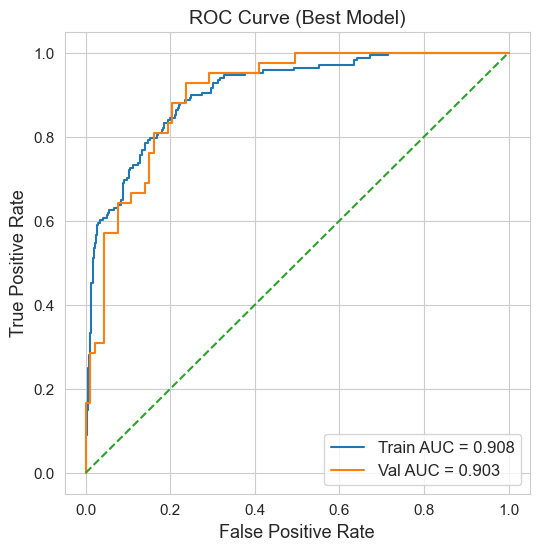

In [245]:
# =========================================================
# SCALE using BEST scaler
# =========================================================

X_train_scaled = best_scaler.transform(X_train)
X_val_scaled = best_scaler.transform(X_val)

# =========================================================
# PREDICT
# =========================================================

train_probs = best_model.predict(X_train_scaled).ravel()
val_probs = best_model.predict(X_val_scaled).ravel()

# =========================================================
# ROC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_tr, tpr_tr, _ = roc_curve(y_train, train_probs)
fpr_val, tpr_val, _ = roc_curve(y_val, val_probs)

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(6,6))

plt.plot(fpr_tr, tpr_tr, label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_val, tpr_val, label=f"Val AUC = {val_auc:.3f}")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Model)")
plt.legend()
plt.show()

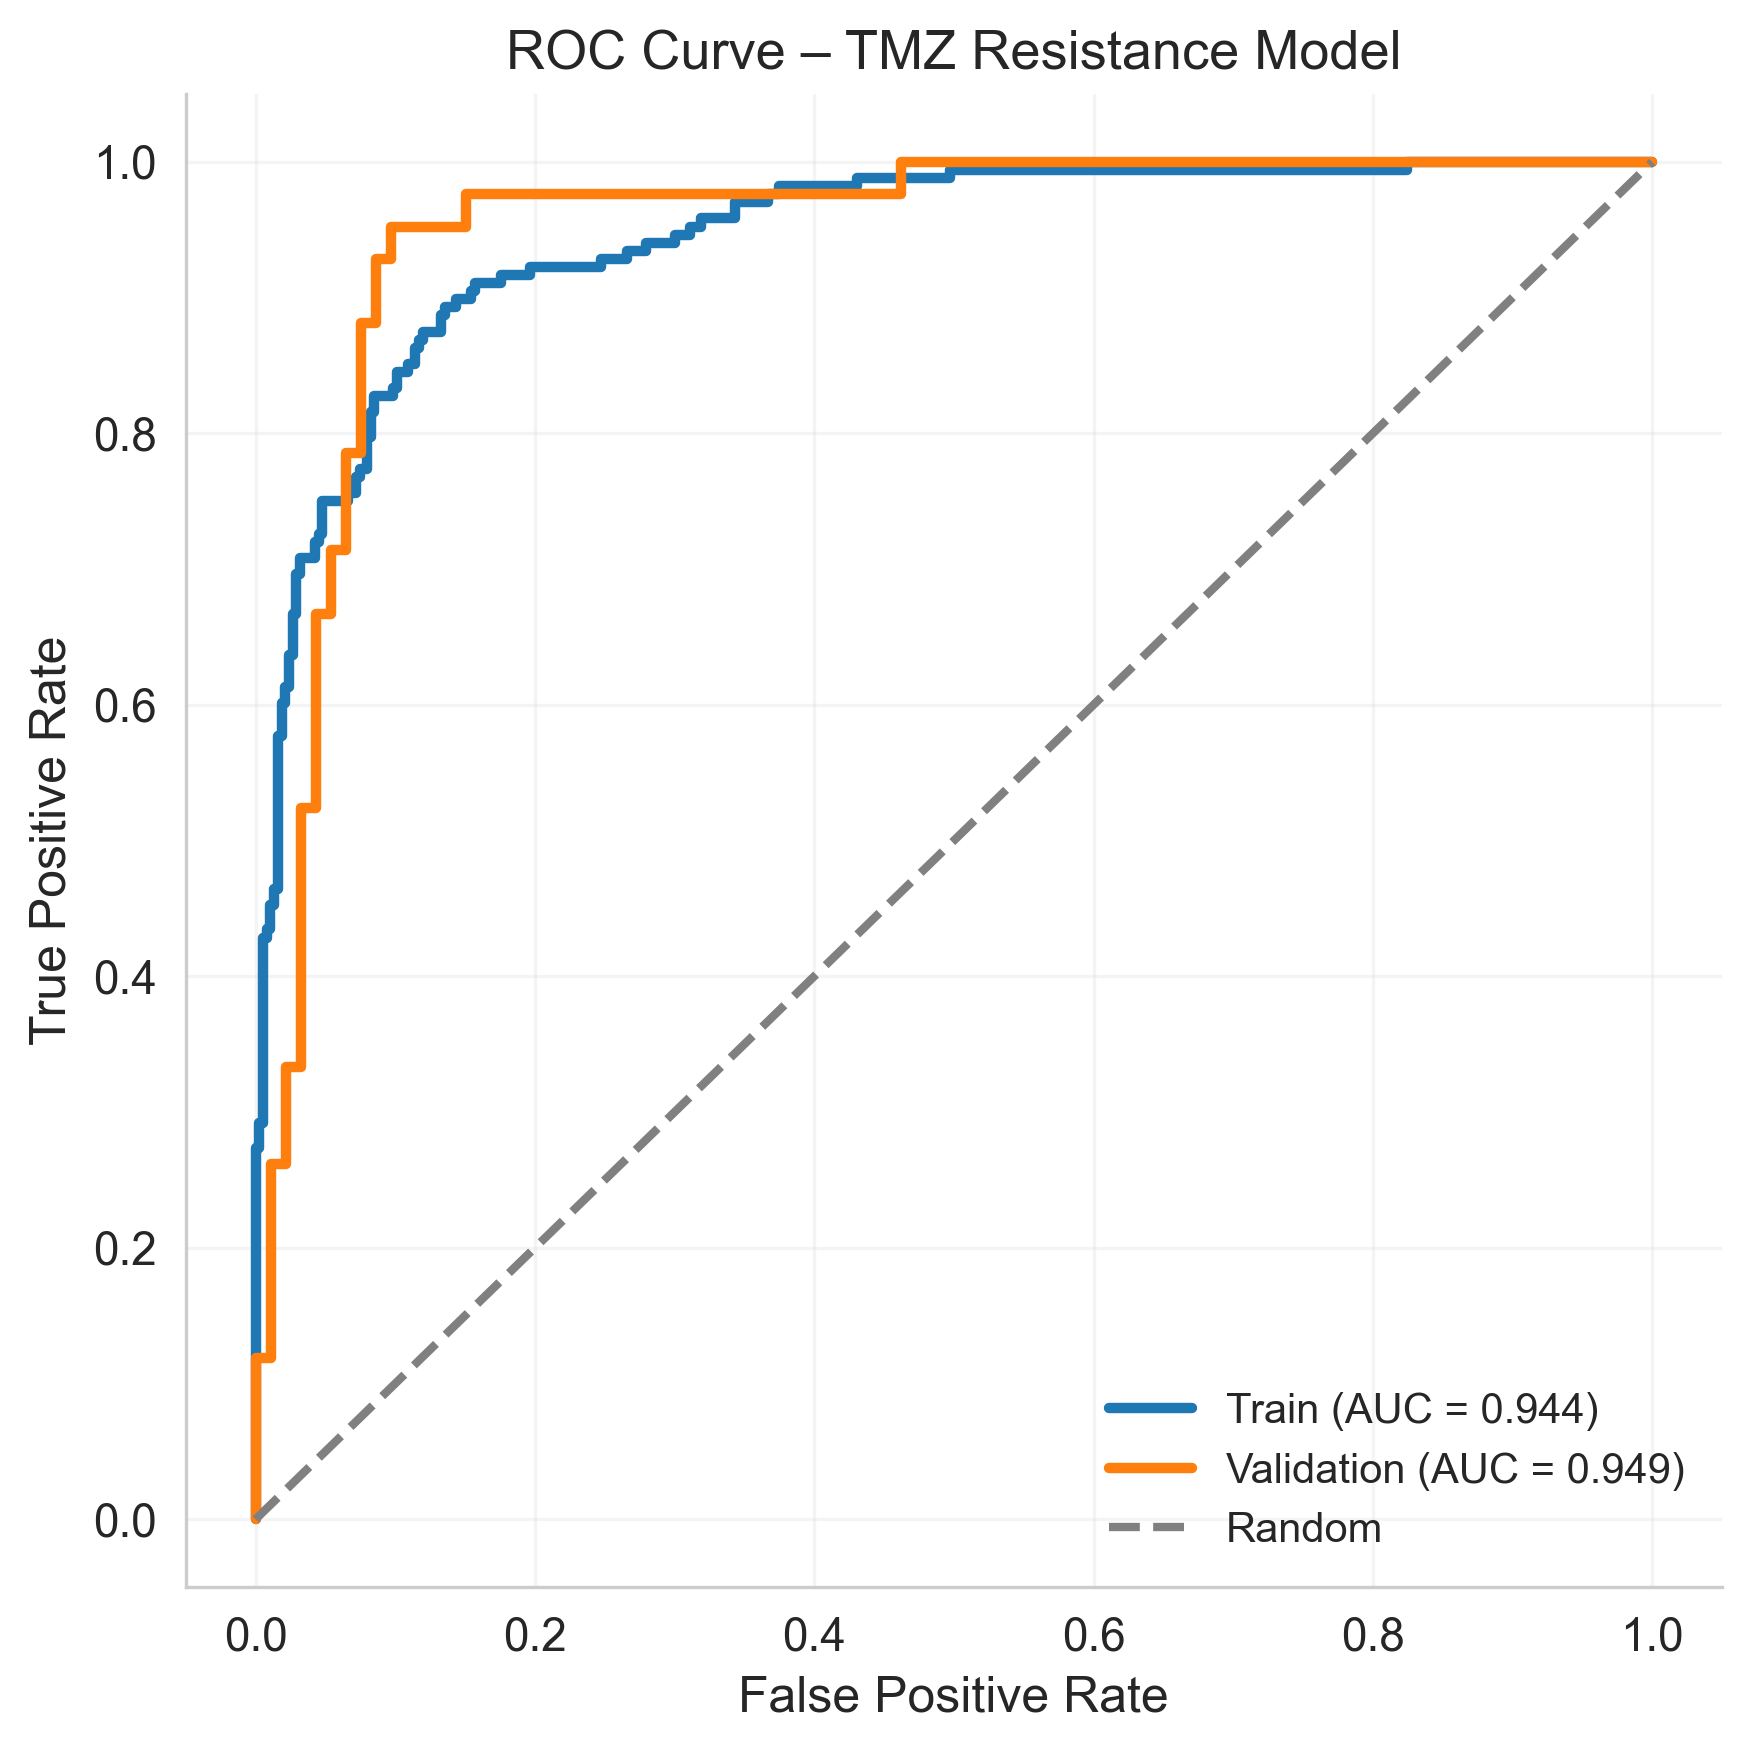

In [288]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# =========================================================
# ROC CURVES
# =========================================================

fpr_tr, tpr_tr, _ = roc_curve(y_train, train_probs)
fpr_val, tpr_val, _ = roc_curve(y_val, val_probs)

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

# =========================================================
# PLOT (PPT / PAPER STYLE)
# =========================================================

plt.figure(figsize=(6, 6), dpi=300)

# Train curve
plt.plot(
    fpr_tr, tpr_tr,
    linewidth=2.5,
    label=f"Train (AUC = {train_auc:.3f})"
)

# Validation curve
plt.plot(
    fpr_val, tpr_val,
    linewidth=2.5,
    label=f"Validation (AUC = {val_auc:.3f})"
)

# Random baseline
plt.plot([0, 1], [0, 1],
         linestyle="--",
         linewidth=2,
         color="gray",
         label="Random")

# Axis styling
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve – TMZ Resistance Model", fontsize=13)

# Clean look (important for PPT)
plt.grid(alpha=0.2)
plt.legend(frameon=False, fontsize=10)

# Make axes thicker (presentation style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# SAVE HIGH QUALITY FIGURE
# =========================================================

plt.tight_layout()
plt.savefig("ROC_curve_TPZ_model.png", dpi=300, bbox_inches="tight")
plt.savefig("ROC_curve_TPZ_model.pdf", bbox_inches="tight")  # best for paper/PPT

plt.show()

In [407]:
# =========================================================
# TCGA PREDICTION (POST-MODEL PROCESSING ONLY)
# =========================================================

tcga_probs = model.predict(X_test_scaled).ravel()

tcga_df = pd.DataFrame({
    "Sample": X_test.index,
    "Resistance_Probability": tcga_probs
})

# =========================================================
# STEP 1: NORMALIZE RISK SCORE (VERY IMPORTANT)
# =========================================================

tcga_df["Risk_Score"] = (
    (tcga_df["Resistance_Probability"] - tcga_df["Resistance_Probability"].min())
    / (tcga_df["Resistance_Probability"].max() - tcga_df["Resistance_Probability"].min() + 1e-8)
)

# =========================================================
# STEP 2: DEFINE BIOLOGICAL GROUPS (QUANTILE-BASED)
# =========================================================

high_cut = tcga_df["Risk_Score"].quantile(0.75)
low_cut = tcga_df["Risk_Score"].quantile(0.25)

def risk_group(p):
    if p >= high_cut:
        return "Resistant"
    elif p <= low_cut:
        return "Sensitive"
    else:
        return "Intermediate"

tcga_df["Risk_Group"] = tcga_df["Risk_Score"].apply(risk_group)

# =========================================================
# STEP 3: SUMMARY
# =========================================================

print("\n=== Risk Group Distribution ===")
print(tcga_df["Risk_Group"].value_counts(normalize=True))

print("\nScore summary:")
print(tcga_df["Risk_Score"].describe())

# =========================================================
# SAVE OUTPUT
# =========================================================

tcga_df.to_csv("TCGA_MLP_predictions.csv", index=False)

print("\nSaved: TCGA_MLP_predictions_2.csv")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

=== Risk Group Distribution ===
Risk_Group
Intermediate    0.499250
Resistant       0.250375
Sensitive       0.250375
Name: proportion, dtype: float64

Score summary:
count    667.000000
mean       0.396258
std        0.231134
min        0.000000
25%        0.205036
50%        0.326447
75%        0.615463
max        1.000000
Name: Risk_Score, dtype: float64

Saved: TCGA_MLP_predictions_2.csv


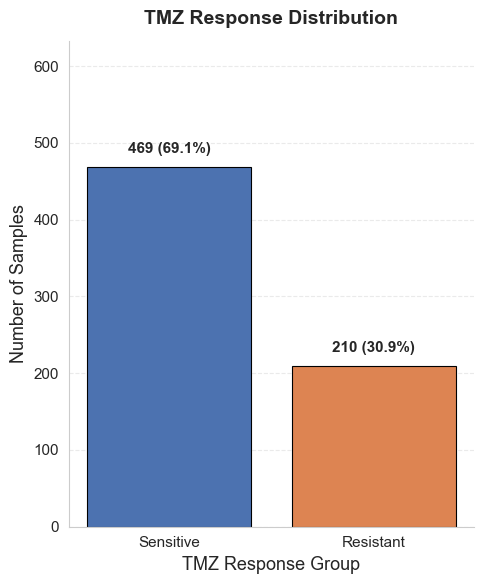

In [408]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# STYLE (PUBLICATION QUALITY)
# =========================================================
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "Arial"
})

# =========================================================
# DATA
# =========================================================
counts = y.value_counts().sort_index()  # ensures 0 then 1

fig, ax = plt.subplots(figsize=(5, 6))

bars = ax.bar(
    counts.index,
    counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    linewidth=0.8
)

total = len(y)
max_h = counts.max()

# =========================================================
# LABELS ABOVE BARS (CLEAN)
# =========================================================
ax.set_ylim(0, max_h * 1.35)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_h * 0.03,
        f"{int(height)} ({height/total:.1%})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# =========================================================
# IMPORTANT: BIOLOGICAL LABELING
# =========================================================
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sensitive", "Resistant"])

ax.set_title("TMZ Response Distribution", pad=12, fontweight="bold")
ax.set_xlabel("TMZ Response Group")
ax.set_ylabel("Number of Samples")

# =========================================================
# CLEAN STYLE
# =========================================================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

plt.tight_layout()

# =========================================================
# SAVE HIGH-QUALITY FIGURE
# =========================================================
plt.savefig("TMZ_distribution_final.png", dpi=600, bbox_inches="tight")
plt.show()

In [409]:
print(X_train.mean().mean())
print(X_test_scaled.mean().mean())

6.02869464570231
-2.6232955504265956


In [410]:
# =========================================================
# DEFINE RESISTANCE USING PERCENTILES
# =========================================================

q75 = tcga_df["Resistance_Probability"].quantile(0.75)
q50 = tcga_df["Resistance_Probability"].quantile(0.50)
q25 = tcga_df["Resistance_Probability"].quantile(0.25)

def risk_group(p):

    if p >= q75:
        return "High Resistant"

    elif p >= q50:
        return "Resistant"

    elif p >= q25:
        return "Sensitive"

    else:
        return "High Sensitive"

tcga_df["Risk_Group"] = (
    tcga_df["Resistance_Probability"]
    .apply(risk_group)
)

In [411]:
# top 20% = resistant
threshold = tcga_df["Resistance_Probability"].quantile(0.80)

tcga_df["Predicted_Resistance"] = (
    tcga_df["Resistance_Probability"] >= threshold
).astype(int)

In [412]:
# =========================================================
# DEFINE TOP 20% AS RESISTANT
# =========================================================

threshold = tcga_df["Resistance_Probability"].quantile(0.80)

tcga_df["Predicted_Resistance"] = (
    tcga_df["Resistance_Probability"] >= threshold
).astype(int)

tcga_df["Risk_Group"] = tcga_df["Predicted_Resistance"].map({
    1: "Resistant",
    0: "Sensitive"
})

# =========================================================
# COUNTS
# =========================================================

counts = tcga_df["Risk_Group"].value_counts()

n_resistant = counts.get("Resistant", 0)
n_sensitive = counts.get("Sensitive", 0)
total = len(tcga_df)

print("\n=== TCGA Risk Group Counts ===")
print(f"Total patients : {total}")
print(f"Resistant      : {n_resistant} ({n_resistant/total:.1%})")
print(f"Sensitive      : {n_sensitive} ({n_sensitive/total:.1%})")

print("\nFull distribution:")
print(counts)


=== TCGA Risk Group Counts ===
Total patients : 667
Resistant      : 134 (20.1%)
Sensitive      : 533 (79.9%)

Full distribution:
Risk_Group
Sensitive    533
Resistant    134
Name: count, dtype: int64


In [345]:
# =========================================================
# CLEAN TCGA IDS
# =========================================================

tcga_df["Sample"] = tcga_df["Sample"].str[:12]
tcga_clin["SAMPLE_ID"] = tcga_clin["SAMPLE_ID"].str[:12]

# =========================================================
# MERGE
# =========================================================

surv_df = tcga_df.merge(
    tcga_clin,
    left_on="Sample",
    right_on="SAMPLE_ID",
    how="inner"
)

print(surv_df.shape)
surv_df.head()

(667, 61)


,Sample,Resistance_Probability,Risk_Score,Risk_Group,SAMPLE_ID,PATIENT_ID,TISSUE_SOURCE_SITE,WHOLE_EXOME_SEQUENCING,WHOLE_GENOME_SEQUENCING,RNASEQ_DATA,...,TMB_NONSYNONYMOUS,STUDY,BCR_STATUS,HISTOLOGICAL_DIAGNOSIS,AGE,SEX,OS_MONTHS,OS_STATUS,KARNOFSKY_PERFORMANCE_SCORE,sample_id
0,TCGA-CS-4938,0.033938,0.210003,Intermediate,TCGA-CS-4938,TCGA-CS-4938,Thomas Jefferson University,Yes,Yes,Yes,...,0.366667,Brain Lower Grade Glioma,IGC,astrocytoma,31.0,Female,4.7,0:LIVING,90.0,TCGA-CS-4938
1,TCGA-CS-4941,0.054094,0.648435,Resistant,TCGA-CS-4941,TCGA-CS-4941,Thomas Jefferson University,Yes,Yes,Yes,...,1.400000,Brain Lower Grade Glioma,IGC,astrocytoma,67.0,Male,7.7,1:DECEASED,90.0,TCGA-CS-4941
2,TCGA-CS-4942,0.036120,0.257476,Intermediate,TCGA-CS-4942,TCGA-CS-4942,Thomas Jefferson University,Yes,No,Yes,...,0.600000,Brain Lower Grade Glioma,IGC,astrocytoma,44.0,Female,43.9,1:DECEASED,90.0,TCGA-CS-4942
3,TCGA-CS-4943,0.038279,0.304432,Intermediate,TCGA-CS-4943,TCGA-CS-4943,Thomas Jefferson University,Yes,No,Yes,...,0.700000,Brain Lower Grade Glioma,IGC,astrocytoma,37.0,Male,18.1,0:LIVING,50.0,TCGA-CS-4943
4,TCGA-CS-4944,0.039564,0.332380,Intermediate,TCGA-CS-4944,TCGA-CS-4944,Thomas Jefferson University,Yes,Yes,Yes,...,0.566667,Brain Lower Grade Glioma,IGC,astrocytoma,50.0,Male,10.6,0:LIVING,90.0,TCGA-CS-4944


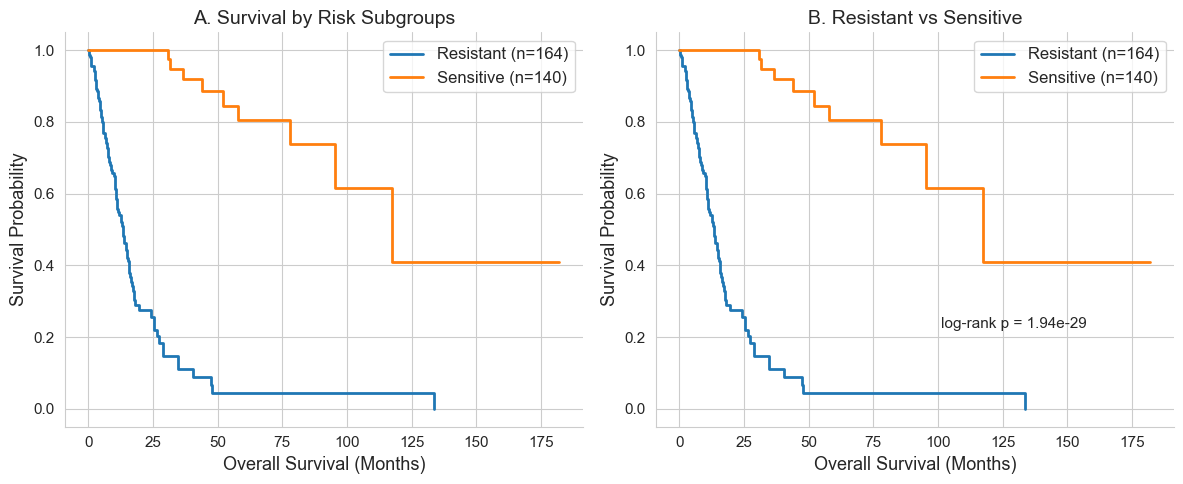


=== SURVIVAL SUMMARY ===
              count       mean  median
Risk_Group                            
Intermediate    303  24.466337   14.70
Resistant       164  11.920732    9.10
Sensitive       140  26.379286   15.25


In [346]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# =========================================================
# CLEAN SURVIVAL DATA
# =========================================================

surv_df["OS"] = pd.to_numeric(surv_df["OS_MONTHS"], errors="coerce")

surv_df["event"] = (
    surv_df["OS_STATUS"]
    .astype(str)
    .str.lower()
    .str.contains("dead|deceased|yes", na=False)
).astype(int)

surv_df = surv_df.dropna(subset=["OS", "Risk_Group"])

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

kmf = KaplanMeierFitter()

# =========================================================
# PANEL A: 4-GROUP KM (DOSE RESPONSE)
# =========================================================

groups = ["High Resistant", "Resistant", "Sensitive", "High Sensitive"]
ax = axes[0]

for g in groups:
    sub = surv_df[surv_df["Risk_Group"] == g]
    
    if len(sub) == 0:
        continue
    
    kmf.fit(sub["OS"], sub["event"], label=f"{g} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=2)

ax.set_title("A. Survival by Risk Subgroups")
ax.set_xlabel("Overall Survival (Months)")
ax.set_ylabel("Survival Probability")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# PANEL B: BINARY KM (CLASSIC PAPER STYLE)
# =========================================================

binary_df = surv_df[surv_df["Risk_Group"].isin(["Resistant", "Sensitive"])].copy()

res = binary_df[binary_df["Risk_Group"] == "Resistant"]
sen = binary_df[binary_df["Risk_Group"] == "Sensitive"]

results = logrank_test(
    res["OS"], sen["OS"],
    event_observed_A=res["event"],
    event_observed_B=sen["event"]
)

ax = axes[1]

kmf.fit(res["OS"], res["event"], label=f"Resistant (n={len(res)})")
kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=2)

kmf.fit(sen["OS"], sen["event"], label=f"Sensitive (n={len(sen)})")
kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=2)

ax.set_title("B. Resistant vs Sensitive")
ax.set_xlabel("Overall Survival (Months)")
ax.set_ylabel("Survival Probability")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.55, 0.25,
    f"log-rank p = {results.p_value:.2e}",
    transform=ax.transAxes,
    fontsize=11
)

plt.tight_layout()
plt.show()

# =========================================================
# PANEL C: SUMMARY CHECK (PRINT ONLY)
# =========================================================

print("\n=== SURVIVAL SUMMARY ===")
print(
    surv_df.groupby("Risk_Group")["OS"].agg(["count", "mean", "median"])
)

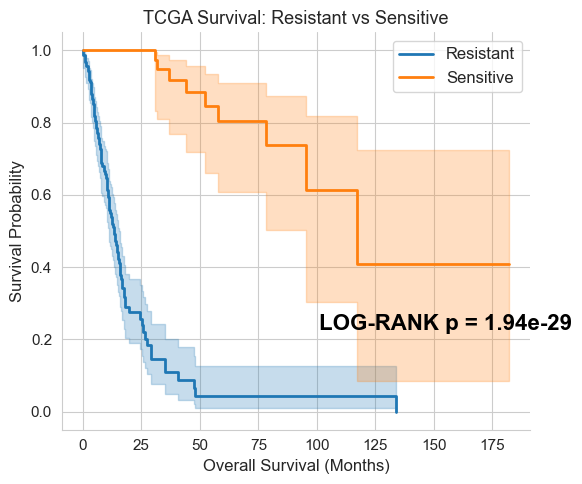

In [347]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# =========================================================
# CLEAN DATA
# =========================================================

surv_df["OS"] = pd.to_numeric(surv_df["OS_MONTHS"], errors="coerce")

surv_df["event"] = (
    surv_df["OS_STATUS"]
    .astype(str)
    .str.lower()
    .str.contains("dead|deceased|yes", na=False)
).astype(int)

surv_df = surv_df.dropna(subset=["OS", "Risk_Group"])

surv_df = surv_df[
    surv_df["Risk_Group"].isin(["Resistant", "Sensitive"])
].copy()

# =========================================================
# SPLIT
# =========================================================

res = surv_df[surv_df["Risk_Group"] == "Resistant"]
sen = surv_df[surv_df["Risk_Group"] == "Sensitive"]

assert len(res) > 0 and len(sen) > 0

# =========================================================
# LOG-RANK TEST
# =========================================================

results = logrank_test(
    res["OS"], sen["OS"],
    event_observed_A=res["event"],
    event_observed_B=sen["event"]
)

# =========================================================
# KM PLOT
# =========================================================

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(6,5))

kmf.fit(res["OS"], res["event"], label="Resistant")
kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2)

kmf.fit(sen["OS"], sen["event"], label="Sensitive")
kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2)

# =========================================================
# BIG LOG-RANK TEXT (IMPORTANT CHANGE)
# =========================================================

ax.text(
    0.55, 0.25,
    f"LOG-RANK p = {results.p_value:.2e}",
    transform=ax.transAxes,
    fontsize=16,   # 👈 BIG TEXT
    fontweight="bold",
    color="black"
)

# =========================================================
# STYLE (NATURE CLEAN)
# =========================================================

ax.set_xlabel("Overall Survival (Months)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)

ax.set_title("TCGA Survival: Resistant vs Sensitive", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [348]:
print(tcga_df["Risk_Group"].value_counts())

Risk_Group
Intermediate    333
Resistant       167
Sensitive       167
Name: count, dtype: int64


In [349]:
surv_df.groupby("Risk_Group")["OS"].mean()

Risk_Group
Resistant    11.920732
Sensitive    26.379286
Name: OS, dtype: float64

In [350]:
print("MIN:", tcga_probs.min())
print("MAX:", tcga_probs.max())
print("MEAN:", tcga_probs.mean())

MIN: 0.024283528
MAX: 0.070256226
MEAN: 0.0425006


In [351]:
import numpy as np
import pandas as pd

# expression matrix (samples × genes)
expr = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=X_test.columns
)

# align groups
resistant_samples = tcga_df.loc[
    tcga_df["Risk_Group"] == "Resistant", "Sample"
]

sensitive_samples = tcga_df.loc[
    tcga_df["Risk_Group"] == "Sensitive", "Sample"
]

res_expr = expr.loc[expr.index.intersection(resistant_samples)]
sen_expr = expr.loc[expr.index.intersection(sensitive_samples)]

In [352]:
# remove near-constant genes
gene_var = expr.var(axis=0)

expr = expr.loc[:, gene_var > 1e-4]

res_expr = expr.loc[res_expr.index]
sen_expr = expr.loc[sen_expr.index]

In [353]:
from scipy.stats import ttest_ind

genes = expr.columns

results = []

for g in genes:

    # skip pathological genes
    if expr[g].std() < 1e-6:
        continue

    stat, p = ttest_ind(
        res_expr[g],
        sen_expr[g],
        equal_var=False,   # Welch correction
        nan_policy="omit"
    )

    results.append([g, stat, p])

deg_df = pd.DataFrame(results, columns=["Gene", "t_stat", "p_value"])

C:\Users\food1\anaconda3\envs\AIclass\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [354]:
from statsmodels.stats.multitest import multipletests

deg_df["adj_p"] = multipletests(
    deg_df["p_value"].fillna(1),
    method="fdr_bh"
)[1]

In [355]:
logFC = []

for g in deg_df["Gene"]:

    fc = np.log2(
        (res_expr[g].mean() + 1e-9) /
        (sen_expr[g].mean() + 1e-9)
    )

    logFC.append(fc)

deg_df["logFC"] = logFC

In [356]:
sig_deg = deg_df[
    (deg_df["adj_p"] < 0.05) &
    (deg_df["logFC"].abs() > 0.25)
].sort_values("adj_p")

print("Significant genes:", sig_deg.shape[0])
sig_deg.head()

Significant genes: 409


,Gene,t_stat,p_value,adj_p,logFC
1658,CLIC1,63.549991,1.210985e-163,3.028674e-160,-0.298785
1007,BMP2,-52.422466,2.434354e-162,3.044159e-159,0.318932
935,FBXO17,47.182392,2.391099e-148,1.993379e-145,-0.443024
2495,DSCAML1,-56.252765,2.219308e-142,1.007515e-139,0.254485
521,ADAM12,47.441397,2.417070e-142,1.007515e-139,-0.453206


In [357]:
print(f"Total genes tested: {len(deg_df)}")
print(f"Significant genes (FDR<0.05 & |logFC|>0.25): {sig_deg.shape[0]}")

up_genes = sig_deg[sig_deg["logFC"] > 0]
down_genes = sig_deg[sig_deg["logFC"] < 0]

print("Upregulated (Resistant):", up_genes.shape[0])
print("Downregulated (Sensitive):", down_genes.shape[0])

Total genes tested: 2501
Significant genes (FDR<0.05 & |logFC|>0.25): 409
Upregulated (Resistant): 135
Downregulated (Sensitive): 274


In [358]:
sig_genes = sig_deg.copy()

sig_genes = sig_genes.dropna(subset=["logFC"])

if "Gene" not in sig_genes.columns:
    sig_genes = sig_genes.reset_index().rename(columns={"index": "Gene"})

top_up = sig_genes.sort_values("logFC", ascending=False).head(10)
top_down = sig_genes.sort_values("logFC", ascending=True).head(10)

print("\nTop 10 Upregulated in Resistant:")
print(top_up[["Gene", "logFC", "adj_p"]])

print("\nTop 10 Downregulated in Resistant:")
print(top_down[["Gene", "logFC", "adj_p"]])


Top 10 Upregulated in Resistant:
        Gene     logFC         adj_p
2232   LTC4S  2.632222  1.157362e-07
1401  ADAM29  2.317326  1.440470e-75
627    KLRC4  1.389252  6.852677e-68
212    SCRT1  1.367460  6.019617e-35
802   ZNF488  1.309130  3.125594e-41
756    LRIT2  1.232055  6.369119e-71
1414   DUSP9  1.117179  1.245090e-65
1080  TAS2R3  0.959919  8.768398e-31
1419  GPR179  0.902275  1.302445e-39
657    SYT10  0.893134  2.571690e-25

Top 10 Downregulated in Resistant:
           Gene     logFC          adj_p
157    HLA-DQA2 -4.049597   5.641281e-28
665       VSTM1 -2.213633   3.668977e-52
616        IDO1 -1.637498   1.978636e-48
1057     FBXO39 -1.598050  2.970997e-108
564    ATP6V0D2 -1.367918   1.047144e-21
294        ISL2 -1.326761   2.219698e-67
2237        PI3 -1.180347   1.230576e-39
605   HIST1H2BH -1.166766   5.395190e-54
1709    SLC2A14 -1.145225   8.564359e-37
1911      IFI30 -1.116510   2.149465e-91


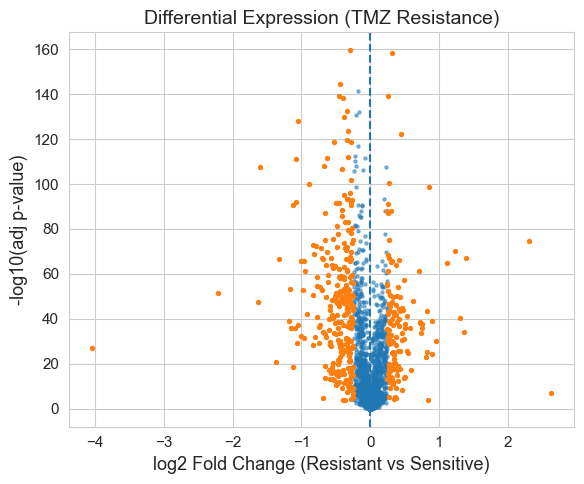

In [359]:
import numpy as np
import matplotlib.pyplot as plt

deg_df["-log10_p"] = -np.log10(deg_df["adj_p"])

plt.figure(figsize=(6,5))

plt.scatter(
    deg_df["logFC"],
    deg_df["-log10_p"],
    s=5,
    alpha=0.5
)

# highlight significant genes
sig = deg_df[(deg_df["adj_p"] < 0.05) & (deg_df["logFC"].abs() > 0.25)]

plt.scatter(
    sig["logFC"],
    -np.log10(sig["adj_p"]),
    s=8
)

plt.axvline(0, linestyle="--")
plt.xlabel("log2 Fold Change (Resistant vs Sensitive)")
plt.ylabel("-log10(adj p-value)")
plt.title("Differential Expression (TMZ Resistance)")
plt.tight_layout()
plt.show()

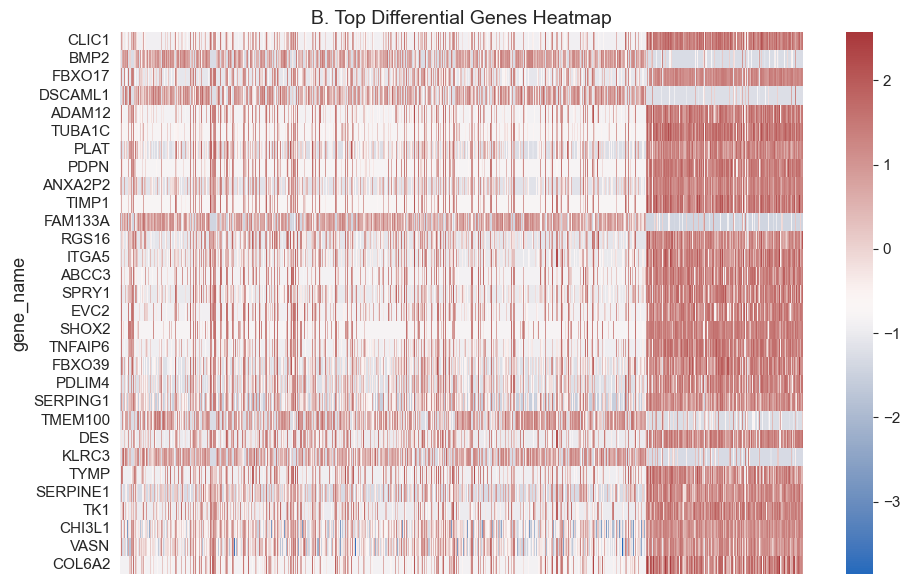

In [360]:
import seaborn as sns

top_genes = sig_deg.sort_values("adj_p").head(30)["Gene"]

heatmap_data = expr[top_genes].copy()

# z-score per gene (important for paper heatmap)
heatmap_data = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

# add group labels
group_labels = tcga_df.set_index("Sample").loc[heatmap_data.index, "Risk_Group"]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data.T,
    cmap="vlag",
    yticklabels=True,
    xticklabels=False,
    cbar=True
)

plt.title("B. Top Differential Genes Heatmap")
plt.tight_layout()

plt.savefig("Fig2B_heatmap.png", dpi=300)
plt.show()

In [368]:
import gseapy as gp

gene_list = sig_deg["Gene"].tolist()

enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2023"],
    organism="homo sapiens",
    outdir="enrichment_results",
    cutoff=0.05
)

# plot top pathways
enr.results.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Hematopoietic cell lineage,14/99,1.404867e-08,0.000003,0,0,8.133552,147.060618,HLA-DRB5;CR1;ITGA4;FLT3;CD3E;CD3D;IL2RA;CD7;IT...
1,KEGG_2021_Human,Th1 and Th2 cell differentiation,10/92,1.856859e-05,0.002052,0,0,5.962773,64.958680,HLA-DRB5;LCK;IL2RA;GATA3;CD3E;HLA-DOA;CD3D;HLA...
2,KEGG_2021_Human,Asthma,6/31,3.365506e-05,0.002479,0,0,11.652208,120.010140,HLA-DRB5;RNASE3;HLA-DOA;HLA-DQA2;HLA-DQA1;HLA-...
3,KEGG_2021_Human,Th17 cell differentiation,10/107,6.897132e-05,0.003811,0,0,5.036819,48.261891,HLA-DRB5;LCK;IL2RA;GATA3;HLA-DOA;CD3E;HLA-DQA2...
4,KEGG_2021_Human,Autoimmune thyroid disease,7/53,9.732738e-05,0.004119,0,0,7.398605,68.344096,HLA-DRB5;GZMB;HLA-DOA;HLA-DQA2;HLA-DQA1;TSHR;H...
5,KEGG_2021_Human,Allograft rejection,6/38,1.118294e-04,0.004119,0,0,9.100031,82.796959,HLA-DRB5;GZMB;HLA-DOA;HLA-DQA2;HLA-DQA1;HLA-DQB1
6,KEGG_2021_Human,Caffeine metabolism,3/6,1.621791e-04,0.004871,0,0,48.246305,421.036301,CYP2A7;CYP2A6;NAT2
7,KEGG_2021_Human,Antigen processing and presentation,8/78,1.919470e-04,0.004871,0,0,5.563520,47.614223,HLA-DRB5;KLRC3;KLRC4;IFI30;HLA-DOA;HLA-DQA2;HL...
8,KEGG_2021_Human,Graft-versus-host disease,6/42,1.983488e-04,0.004871,0,0,8.087262,68.947821,HLA-DRB5;GZMB;HLA-DOA;HLA-DQA2;HLA-DQA1;HLA-DQB1
9,KEGG_2021_Human,Type I diabetes mellitus,6/43,2.265808e-04,0.005007,0,0,7.868285,66.033868,HLA-DRB5;GZMB;HLA-DOA;HLA-DQA2;HLA-DQA1;HLA-DQB1


In [362]:
import numpy as np
import matplotlib.pyplot as plt

def pathway_class(term):
    term = term.lower()

    # Adaptive immunity
    if any(x in term for x in [
        "t cell", "th1", "th2", "th17",
        "hematopoietic", "antigen",
        "allograft", "autoimmune", "diabetes"
    ]):
        return "Adaptive immune response"

    # Innate immunity
    elif any(x in term for x in [
        "phagosome", "complement",
        "coagulation", "infection"
    ]):
        return "Innate immune response"

    # Signaling / neural
    elif any(x in term for x in [
        "neuroactive", "receptor", "synapse", "nicotine"
    ]):
        return "Neuro / receptor signaling"

    # Metabolism
    elif "metabolism" in term or "caffeine" in term:
        return "Metabolic pathways"

    else:
        return "Other biological processes"

C:\Users\food1\AppData\Local\Temp\ipykernel_17520\884989554.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


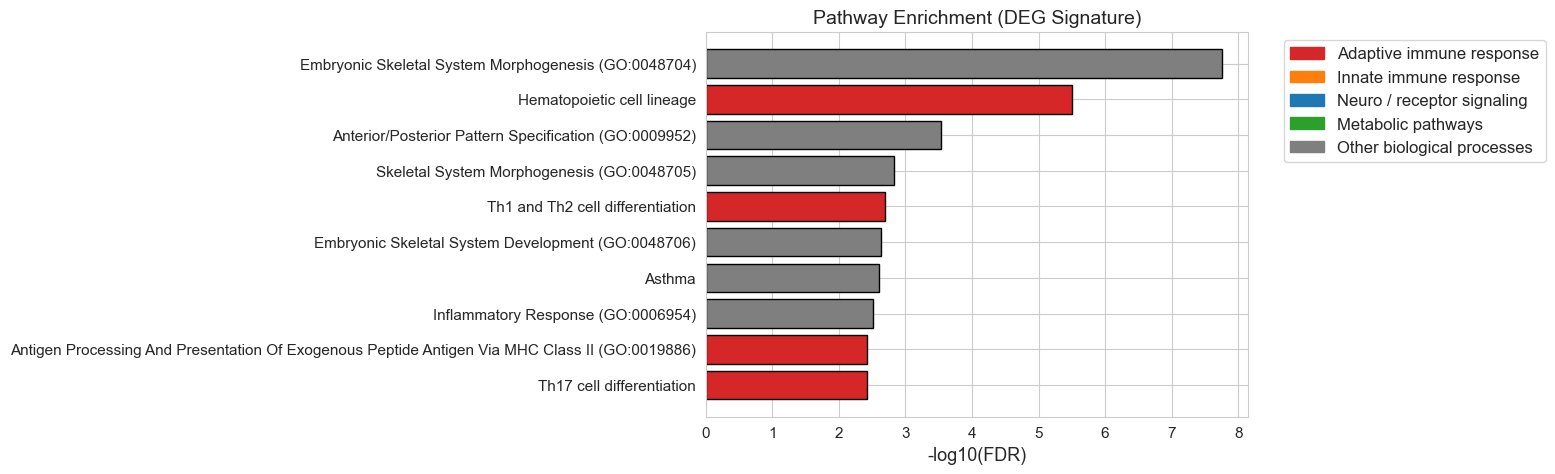

In [363]:
# =========================================================
# PREP TOP PATHWAYS
# =========================================================

top_pathways = enr.results.sort_values(
    "Adjusted P-value"
).head(10).copy()

top_pathways["score"] = -np.log10(top_pathways["Adjusted P-value"])
top_pathways["Class"] = top_pathways["Term"].apply(pathway_class)

# color map
colors = {
    "Adaptive immune response": "#d62728",
    "Innate immune response": "#ff7f0e",
    "Neuro / receptor signaling": "#1f77b4",
    "Metabolic pathways": "#2ca02c",
    "Other biological processes": "#7f7f7f"
}

# =========================================================
# BARPLOT
# =========================================================

plt.figure(figsize=(7,5))

bars = plt.barh(
    top_pathways["Term"],
    top_pathways["score"],
    color=[colors[x] for x in top_pathways["Class"]],
    edgecolor="black"
)

plt.xlabel("-log10(FDR)")
plt.title("Pathway Enrichment (DEG Signature)")
plt.gca().invert_yaxis()

# legend
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color=v, label=k)
    for k, v in colors.items()
]

plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.savefig("Fig2C_Pathway_Barplot.png", dpi=300)
plt.show()

In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = enr.results.copy()

# keep significant only
df = df[df["Adjusted P-value"] < 0.05].copy()

# -log10(FDR)
df["score"] = -np.log10(df["Adjusted P-value"])

In [374]:
def classify_pathway(term):
    immune = [
        "Hematopoietic", "Th1", "Th2", "Th17", "Asthma",
        "Autoimmune", "Allograft", "Graft", "Type I diabetes",
        "Antigen", "Leishmaniasis", "IgA"
    ]
    
    neuro = [
        "Neuroactive", "GABA", "Serotonergic", "Nicotine",
        "Morphine", "Calcium", "cAMP", "Endocannabinoid"
    ]
    
    metabolism = [
        "Caffeine", "ABC transporters", "Metabolism"
    ]
    
    ec_m = [
        "Complement", "Coagulation", "Phagosome", "Axon guidance"
    ]
    
    for x in immune:
        if x in term:
            return "Adaptive immune response"
    for x in neuro:
        if x in term:
            return "Neuroactive signaling"
    for x in metabolism:
        if x in term:
            return "Metabolism / detox"
    for x in ec_m:
        if x in term:
            return "Microenvironment / ECM"
    
    return "Other"


df["Category"] = df["Term"].apply(classify_pathway)

In [375]:
top = (
    df.sort_values("score", ascending=False)
      .groupby("Category")
      .head(3)   # top 3 per group
)

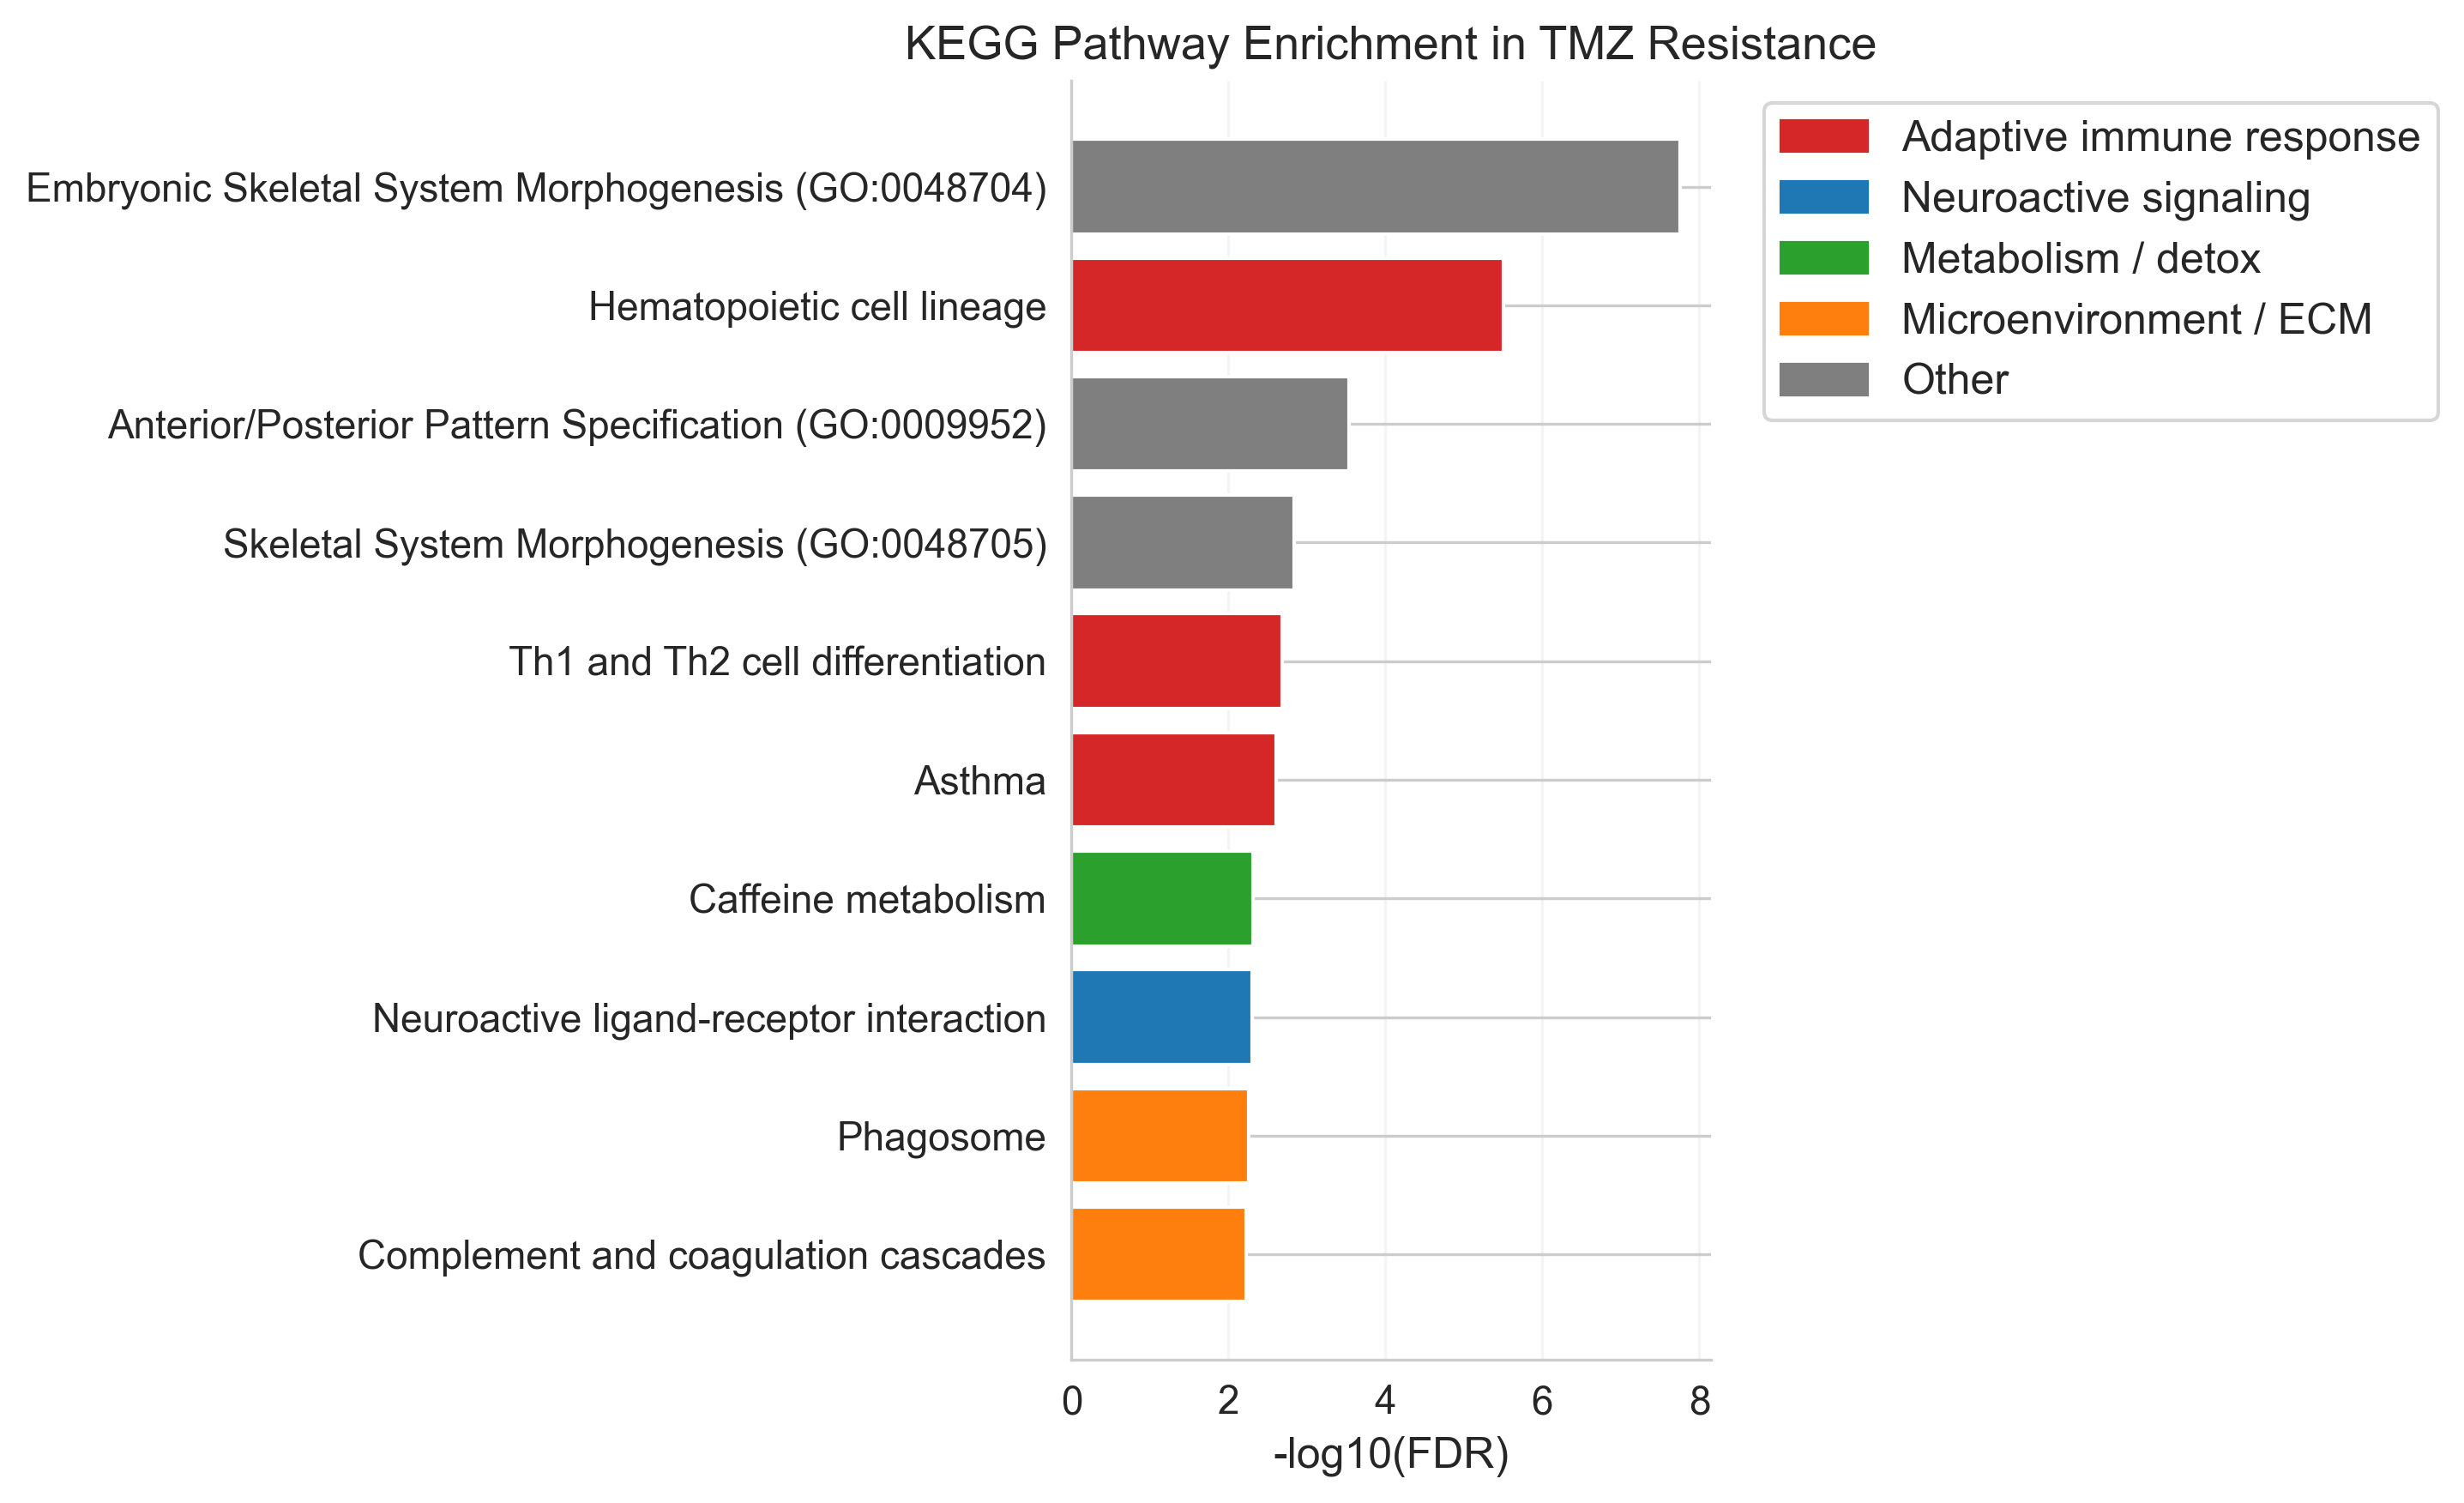

In [376]:
plt.figure(figsize=(10,6), dpi=300)

colors = {
    "Adaptive immune response": "#d62728",
    "Neuroactive signaling": "#1f77b4",
    "Metabolism / detox": "#2ca02c",
    "Microenvironment / ECM": "#ff7f0e",
    "Other": "#7f7f7f"
}

# sort for better visualization
top = top.sort_values("score")

plt.barh(
    top["Term"],
    top["score"],
    color=[colors[c] for c in top["Category"]]
)

plt.xlabel("-log10(FDR)", fontsize=12)
plt.title("KEGG Pathway Enrichment in TMZ Resistance", fontsize=13)

# legend manually
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k,v in colors.items()]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis="x", alpha=0.2)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("KEGG_grouped_barplot.png", dpi=300, bbox_inches="tight")
plt.savefig("KEGG_grouped_barplot.pdf", bbox_inches="tight")

plt.show()

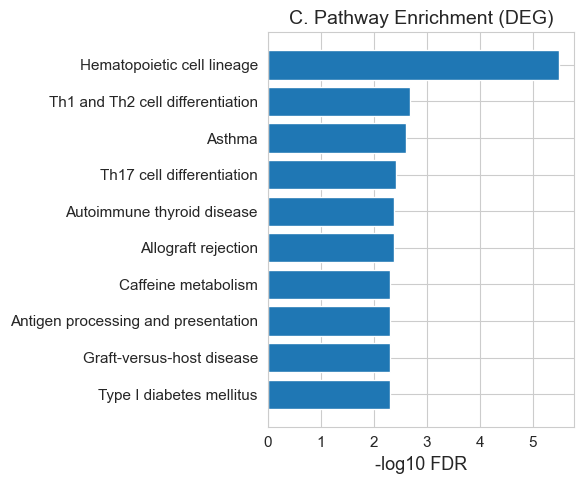

In [366]:
top_pathways = enr.results.head(10)

plt.figure(figsize=(6,5))

plt.barh(
    top_pathways["Term"],
    -np.log10(top_pathways["Adjusted P-value"])
)

plt.xlabel("-log10 FDR")
plt.title("C. Pathway Enrichment (DEG)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("Fig2C_pathway.png", dpi=300)
plt.show()

In [270]:
top_survival_genes = sig_deg.sort_values("adj_p").head(5)["Gene"]

In [271]:
# ensure same index format
expr_T = expr.copy()
expr_T.index.name = "Sample"

surv_df = surv_df.set_index("Sample")

# align samples
common = surv_df.index.intersection(expr_T.index)

surv_df = surv_df.loc[common]
expr_T = expr_T.loc[common]

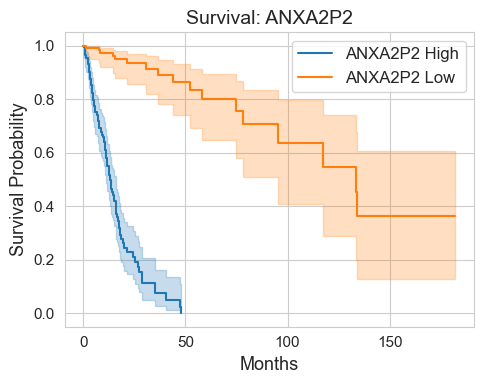

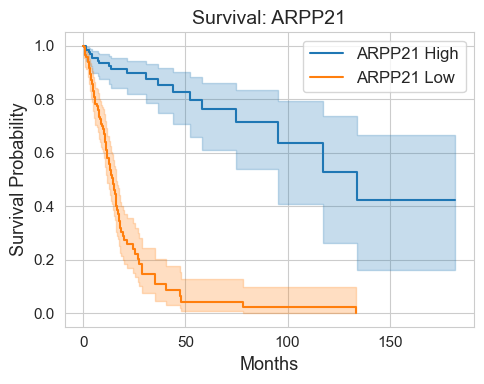

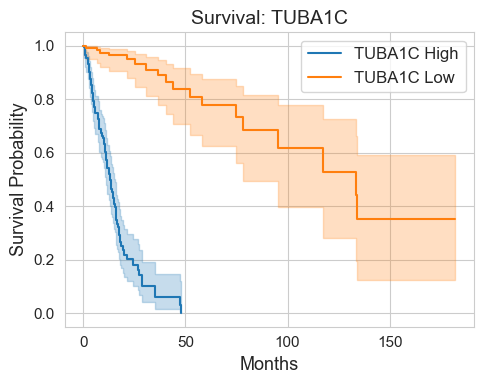

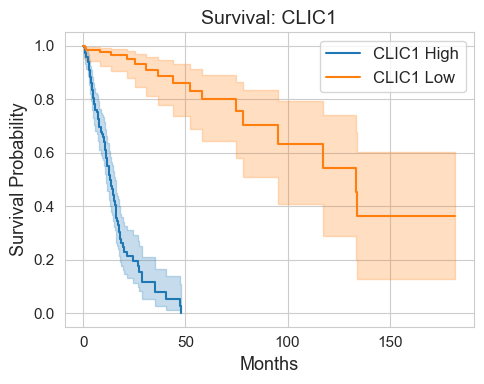

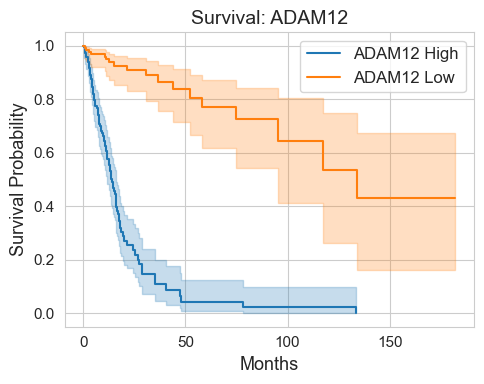

In [272]:
from lifelines import KaplanMeierFitter

top_survival_genes = sig_deg["Gene"].head(5)

kmf = KaplanMeierFitter()

for g in top_survival_genes:

    # SAFE CHECK (IMPORTANT)
    if g not in expr_T.columns:
        print(f"Skipping {g} (not in expression matrix)")
        continue

    surv_df[g] = expr_T[g]

    median_val = surv_df[g].median()

    surv_df[g + "_high"] = surv_df[g] >= median_val

    high = surv_df[surv_df[g + "_high"] == True]
    low  = surv_df[surv_df[g + "_high"] == False]

    if len(high) == 0 or len(low) == 0:
        continue

    plt.figure(figsize=(5,4))

    kmf.fit(high["OS_MONTHS"], high["event"], label=f"{g} High")
    ax = kmf.plot_survival_function()

    kmf.fit(low["OS_MONTHS"], low["event"], label=f"{g} Low")
    kmf.plot_survival_function(ax=ax)

    plt.title(f"Survival: {g}")
    plt.xlabel("Months")
    plt.ylabel("Survival Probability")

    plt.tight_layout()
    plt.show()

In [273]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. SAMPLE DATA (IMPORTANT for speed + stability)
# =========================================================

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
X_shap = X_val[:200]

# =========================================================
# 2. EXPLAINER
# =========================================================

explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_shap)

# binary classification fix
shap_values = shap_values[0]

# =========================================================
# 3. FEATURE NAMES (genes)
# =========================================================

feature_names = X.columns if hasattr(X, "columns") else [f"Gene_{i}" for i in range(X_shap.shape[1])]

# =========================================================
# 4. SHAP SUMMARY (BEESWARM)
# =========================================================

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance (TMZ Resistance)")
plt.tight_layout()
plt.savefig("SHAP_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 5. SHAP BAR PLOT (TOP GENES)
# =========================================================

plt.figure(figsize=(8,5))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Top Predictive Genes (SHAP)")
plt.tight_layout()
plt.savefig("SHAP_bar.png", dpi=300, bbox_inches="tight")
plt.show()

KeyError: "None of [Index([501, 540, 469, 408, 381, 498, 137, 361, 141, 273, 527, 193, 256,  44,\n       440, 238, 496,  52,   2,  65, 450, 311, 317, 289, 172, 140,  76, 145,\n       265, 529,  71, 365,  22, 492, 460, 483, 405, 385, 543, 291,  92, 264,\n       462, 117, 339, 154, 196, 508,  98, 155, 152,  14, 268, 166, 453, 428,\n        37, 452,  48, 390, 444, 301, 116, 236, 455, 125, 407, 474,  55, 324,\n       306, 432, 267, 337,  28, 461, 227, 470, 433, 135, 391,  35, 541, 423,\n       175, 185, 123, 169, 417, 513, 313, 275, 142,  38, 112, 435, 151, 181,\n       229, 206],\n      dtype='int32', name='gene_name')] are in the [columns]"